# 1.2 Stations

Let's consider a full graph of N stations, with routes from each station to every other station, equal transit times between any two stations, but with all stations having different demand (probability of a rental).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [48]:
n_stations = 5
n_levels = 5 # How many levels of demand are there
default_demand = 0.5 # Order frequency, betweeen 0 and 1. 
                     # If too low, many runs would be wasted. If too high, total_n_orders won't be binomial.
n_steps_preparation = 50000 # For how many steps stats are NOT collected
n_steps_per_experiment = 2000
n_experiments = 100
n_cars = 20

n_steps =  n_steps_preparation + n_steps_per_experiment*n_experiments  # Full number of steps to run

demand_levels = (np.arange(n_levels, 0, -1)/n_levels * default_demand).tolist()
print(f"Demand levels to distribute across stations: {demand_levels}")
demand = (demand_levels * int(np.ceil(n_stations / n_levels)))[:n_stations] # Circular sampling, in case n_levels < n_stations
print(f"Demand values at stations: {demand}")

Demand levels to distribute across stations: [0.5, 0.4, 0.3, 0.2, 0.1]
Demand values at stations: [0.5, 0.4, 0.3, 0.2, 0.1]


In [49]:
# Main loop

np.random.seed(1)
cm1 = np.zeros(shape=(n_experiments, n_stations))
average_cars = np.zeros(shape=(n_experiments, n_stations))
total_attempts = np.zeros(shape=(n_experiments, n_stations))
total_rentals = np.zeros(shape=(n_experiments, n_stations))

state_history = np.zeros(shape=(n_steps_per_experiment, n_stations)) # Will only remember one run

state = np.array([n_cars] + [0]*(n_stations-1)) # Case of all cars injected in the hot tile
#state = np.array([n_cars // n_stations]*n_stations) # Case of cars being distributed uniformly
state[0] = n_cars - state[1:].sum() # Only needed for uniform cas (to make sure n_cars is right)
print("Initial cars distribution across stations:", state)
i_experiment = 0
    
for i_step in range(n_steps):
    # Simulation. From each location, we only move one car at best.
    attempts = (np.random.uniform(size=n_stations) < demand) # attempts to rent a single car
    departures = attempts * (state > 0) # But the car only departs if there was a car there to begin with
    destinations = np.random.choice(
        n_stations, size=n_stations, p=np.array(demand)/sum(demand)) # Where a car would go if rented.

    destinations[~departures] = -1 # A necessary correction: if a car didn't leave, then it doesn't arrive anywhere
    arrivals = [sum(destinations==i) for i in range(n_stations)] # Manual pivot table

    state = state - departures + arrivals

    if i_step < n_steps_preparation: # Let the cars distribute
        if i_step % n_steps_per_experiment ==  0:
            print(".", end='')

    if i_step > n_steps_preparation: # Collect stats         
        cm1[i_experiment, :] += (departures + arrivals)/2/n_steps_per_experiment  # Symmetric allocation
        average_cars[i_experiment, :] += state/n_steps_per_experiment
        total_attempts[i_experiment, :] += attempts*1
        total_rentals[i_experiment, :] += departures*1

        if (n_steps - i_step) < n_steps_per_experiment: # Last run, collect data for the plot
            state_history[(i_step - n_steps_preparation) % n_steps_per_experiment, :] = state

        if (i_step - n_steps_preparation) % n_steps_per_experiment == 0:
            # Start a new data collection segment
            print("|", end='')
            i_experiment = (i_step - n_steps_preparation) // n_steps_per_experiment # Experiment counter
        
    
print("Done")

Initial cars distribution across stations: [20  0  0  0  0]
.........................|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Done


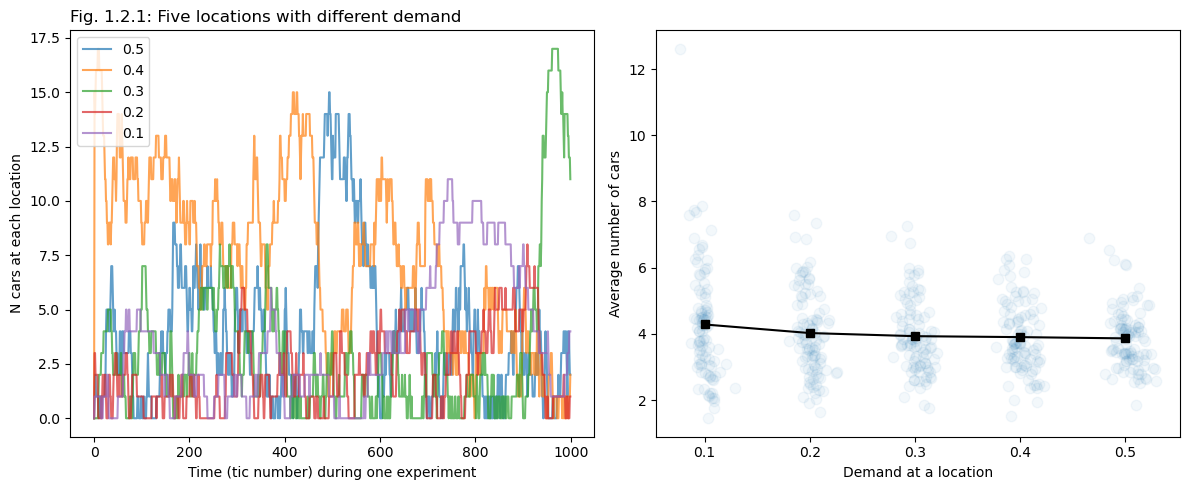

In [50]:
# Plot and save the figure

plt.figure(figsize=(12, 5), facecolor='white')
max_history = 1000

# The tracks from one (last) experiment
plt.subplot(121)
plt.title("Fig. 1.2.1: Five locations with different demand", loc='left')
plt.plot(state_history[:max_history, :], alpha=0.7);
if n_stations <= 5:
    plt.legend(labels=[f"{d}" for d in demand]);
plt.xlabel("Time (tic number) during one experiment")
plt.ylabel("N cars at each location");

# Combined results
plt.subplot(122)
#plt.plot(list(demand)*n_experiments, history.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(total_attempts.flatten()/n_steps_per_experiment, average_cars.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(demand, average_cars.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("Average number of cars");

plt.tight_layout()
plt.savefig("../figures/01simple_02stations_01ncars.svg", dpi=300)

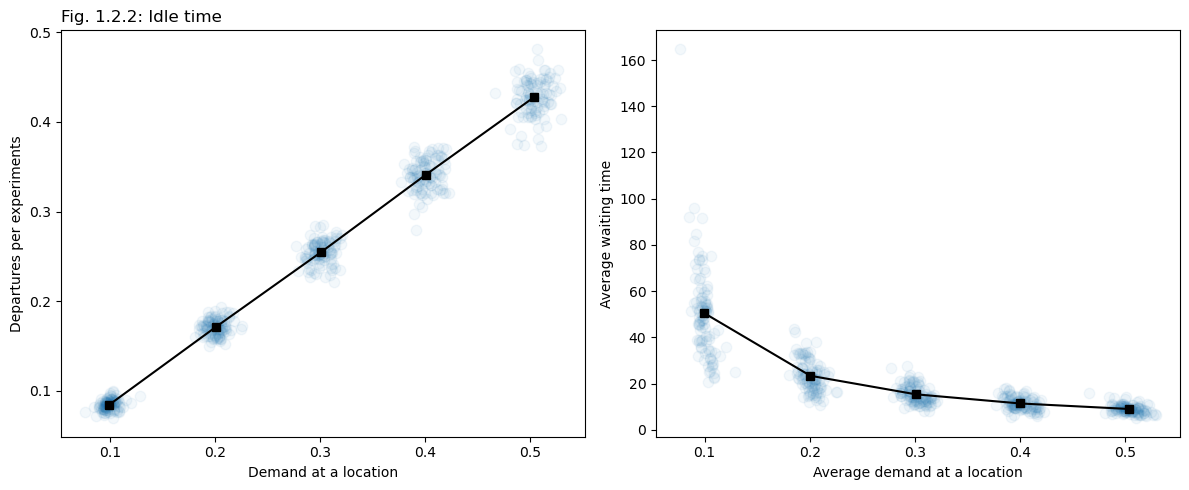

In [51]:
# Plot and save the figure

plt.figure(figsize=(12, 5), facecolor='white')

# The tracks from one (last) experiment
plt.subplot(121)
plt.title("Fig. 1.2.2: Idle time", loc='left')
x = total_attempts/n_steps_per_experiment
y = total_rentals/n_steps_per_experiment
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("Departures per experiments");

# Combined results
plt.subplot(122)
y = average_cars / total_rentals * n_steps_per_experiment
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.05, markersize=15);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Average demand at a location")
plt.ylabel("Average waiting time");  # Approximation
# Strictly speaking, it's not an average of idle times for individual cars, but the average ratio of
# waiting hours (time ticks) to the number of departures. They just happen to be the same ;)

plt.tight_layout()
plt.savefig("../figures/01simple_02stations_02idle.svg", dpi=300)

To compare cars to trips we need to very roughly convert both of them to money. Let's assume that our most high-demand location experiences about 20 departing cars per day, on average. We assumed earlier the highest demand location had 0.5 probability of car departure per tick, which means that to move from trips per trick to trips per day we need to multiply it by `20/0.5 = 40` (then the daily averages will match). It's a weird number, but it's just a reasonable scaling coefficient.

Let's also assume that every trip provides us with 5€ in CM1 (roughly equivalent to 10€ in revenue). It means that multiplying the number of departures by `40*5` gives us an estimation of CM1 per day generated by this location in this experiment.

On the other hand, let's assume that a car costs us 20€/day to lease. Which means that the CM2 burden generated by this location is equal to the average number of cars multiplied by 20.

And also it means, that if we plot CM2 against CM2, the  profitability threshold will look like a line with a slope of `40*5/20`

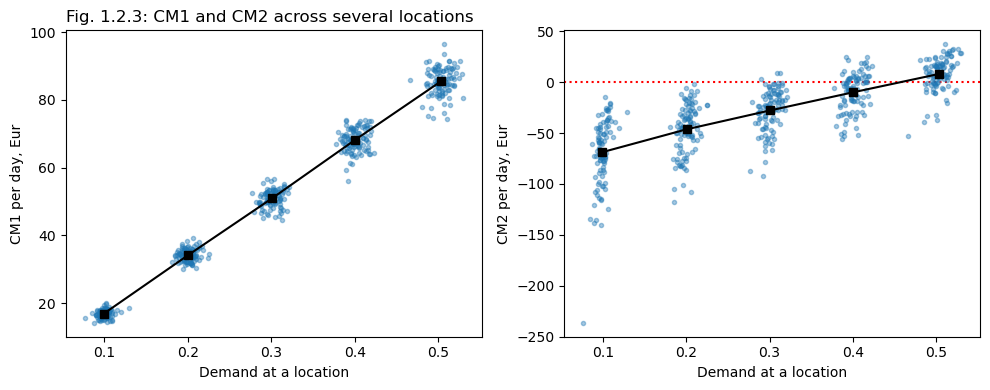

In [76]:
# Financial measures measures
slope = (40*5)/20

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 1.2.3: CM1 and CM2 across several locations", loc='left')
x = total_attempts/n_steps_per_experiment
y = cm1 *40*5
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.4);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("CM1 per day, Eur")

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
y = cm1*40*5 - average_cars*20
plt.plot(x.flatten(), y.flatten(), '.', alpha=0.4);
plt.plot(x.mean(axis=0), y.mean(axis=0), 'ks-')
plt.xlabel("Demand at a location")
plt.ylabel("CM2 per day, Eur")

plt.tight_layout()

plt.savefig("../figures/01simple_02stations_03financials.svg", dpi=300)

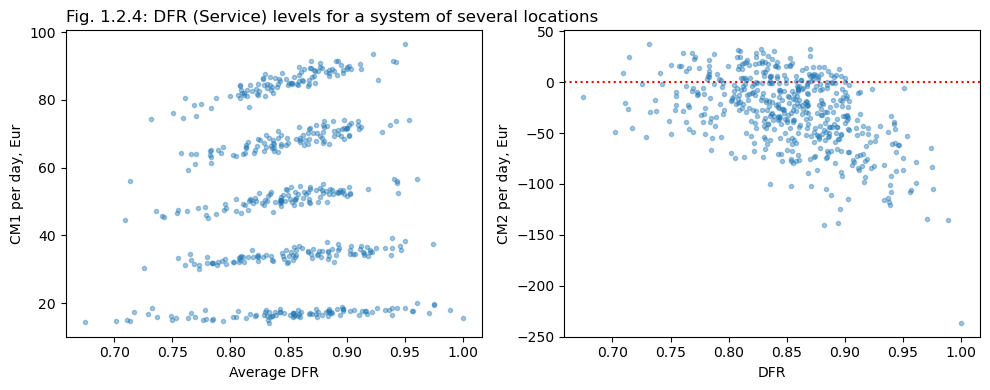

In [79]:
# DFR
dfr = total_rentals/total_attempts

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("Fig. 1.2.4: DFR (Service) levels for a system of several locations", loc='left')
plt.plot(dfr.flatten(), cm1.flatten()*40*5, '.', alpha=0.4);
plt.xlabel("Average DFR")
plt.ylabel("CM1 per day, Eur")

plt.subplot(122)
plt.axhline(0, color='red', linestyle=':')
cm2 = cm1*40*5 - average_cars*20
plt.plot(dfr.flatten(), cm2.flatten(), '.', alpha=0.4);
plt.xlabel("DFR")
plt.ylabel("CM2 per day, Eur");

plt.tight_layout()

plt.savefig("../figures/01simple_02stations_04dfr.svg", dpi=300)

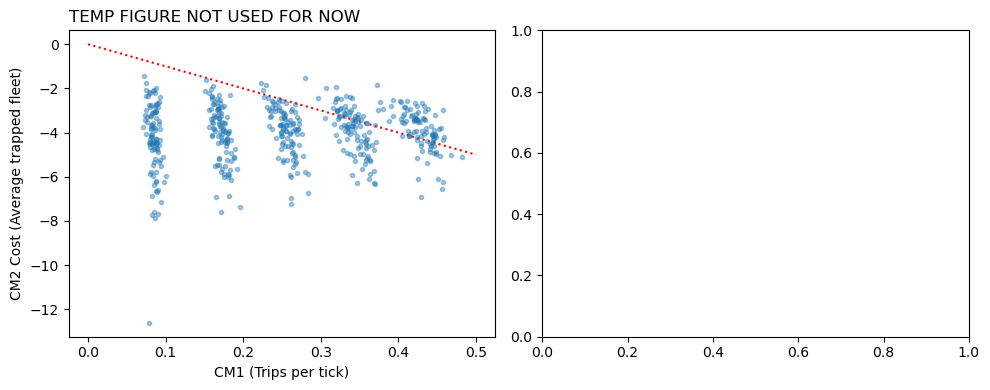

In [68]:
# Financial measures measures
slope = (40*5)/20

plt.figure(figsize=(10,4));
plt.subplot(121)
plt.title("TEMP FIGURE NOT USED FOR NOW", loc='left')
plt.plot([0, 0.5], -np.array([0, 0.5])*slope, 'r:')
plt.plot(cm1.flatten(), -average_cars.flatten(), '.', alpha=0.4);
plt.xlabel("CM1 (Trips per tick)")
plt.ylabel("CM2 Cost (Average trapped fleet)");

plt.subplot(122)

plt.tight_layout()

This plot illustrates several important points
* On average, trapped fleet was distributed equally between the stations. Without forceful fleet redistribution, cars tend to spread unformly across the landscape (which is bad for business, and will be addressed in next chapters).
* Stations with high volume (clusters of points on the right of the plot) were always profitable (are always below the break-even line). Even when the number of cars was high (points on the upper side of the cluster), the generated revenue compensated the costs of fleet.
* Stations with low volumes (cluster on the left side of the plot) were never profitable (the entire cluster lies above the break-even line). Even when by pure luck the station only had around 1 car stuck there, the revenues did not justify this investment. In a real-world situation, we would have recommended to close these stations.
* Stations in the middle were profitable sometimes (when by pure luck the fleet in them was low), but were unprofitable on other runs (when by pure unluck the fleet was high). The break-even line crosses their clusters, cutting them in two. This observation raises a question: is it possible to guarantee that a station wouldn't accumulate too much fleet, just by pure luck? The answer to this question is a resounding "Yes", as you can always relocate trapped cars elsewhere; we will return to this topic in the next chapter).
* Within each a cloud of points, for each station separately, points that are low on the Y-axis (runs that had few cars in the station) also tend to be somewhat left on the X-axis (demonstrate fewer number of trips, and thus lower revenues). The reason for this pattern are missed sales (missed rentals) that happen when the number of cars hits 0, and the station stays empty. The interesting thing here, howeveer, is that a few missed sales (some unfulfilled demand) does not necessarily ruin profitability, precisely because it is accompanied by lower values of trapped fleet, allowing this fleet to, supposedly, earn money elsewhere. The reasons that unfulfilled demand is dangerous is that it can damage customer trust, and thus harm the business in the long-term, but short-term it does not hurt CM2 values that much.
* The spread of average fleet values was larger for smaller stations. This is because the number of cars trapped at small stations changes slowly, so even after averaging over time there's luck involved in what value you'll get. At large stations, on the other hand, cars leave and arrive all the time, making averaging over time more effective. A business consequence of this finding is that it is not that easy to predict if a small location will be profitable in the long-run, based on its actual performance over a short period of time. It is much more efficient to measure the demand at the station, and then calculate the expected profitability, assuming this demand and optimal fleet management. 